# Visualizaciones tipo Mundial — Inglaterra 6-2 Irán (Qatar 2022)

Con **datos de eventos reales** de StatsBomb Open Data (descargados con
`scripts/download_statsbomb.py`) construimos las tres visualizaciones clásicas
del análisis de fútbol:

1. **Shot map** — cada tiro con su ubicación y su xG (tamaño del punto)
2. **Mapa de calor de toques** — dónde jugó Inglaterra (estimación de densidad KDE)
3. **Red de pases** — posiciones medias del once inicial y volumen de pases entre jugadores

Coordenadas StatsBomb: cancha de 120x68 (x hacia el arco rival), cada evento
trae `location = [x, y]` y los tiros traen `shot.statsbomb_xg`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mplsoccer import Pitch, VerticalPitch

DATA = Path("..") / "data" / "raw" / "statsbomb"
FIGS = Path("..") / "reports" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

MATCH_ID = 3857271  # England 6-2 Iran, fase de grupos Qatar 2022
TEAM_A, TEAM_B = "England", "Iran"
# Par categórico azul/naranja: distinguible con visión normal y con daltonismo
COLOR_A, COLOR_B = "#1a78cf", "#e66100"
PITCH_KW = dict(pitch_type="statsbomb", pitch_color="#f8f9fa", line_color="#495057", linewidth=1)

events = json.load(open(DATA / "events" / f"{MATCH_ID}.json", encoding="utf-8"))
df = pd.json_normalize(events, sep="_")
print(f"{len(df)} eventos, {df.type_name.nunique()} tipos distintos")
df.type_name.value_counts().head(10)

3649 eventos, 26 tipos distintos


type_name
Pass              1093
Ball Receipt*     1027
Carry              850
Pressure           242
Ball Recovery       84
Duel                55
Block               30
Foul Committed      30
Clearance           28
Interception        27
Name: count, dtype: int64

## 1. Shot map con xG

Cada punto es un tiro; el **área del punto es proporcional al xG** (la probabilidad
de gol que el modelo de StatsBomb le asigna). Goles rellenos, fallos huecos.
Inglaterra ataca hacia la derecha; Irán hacia la izquierda.

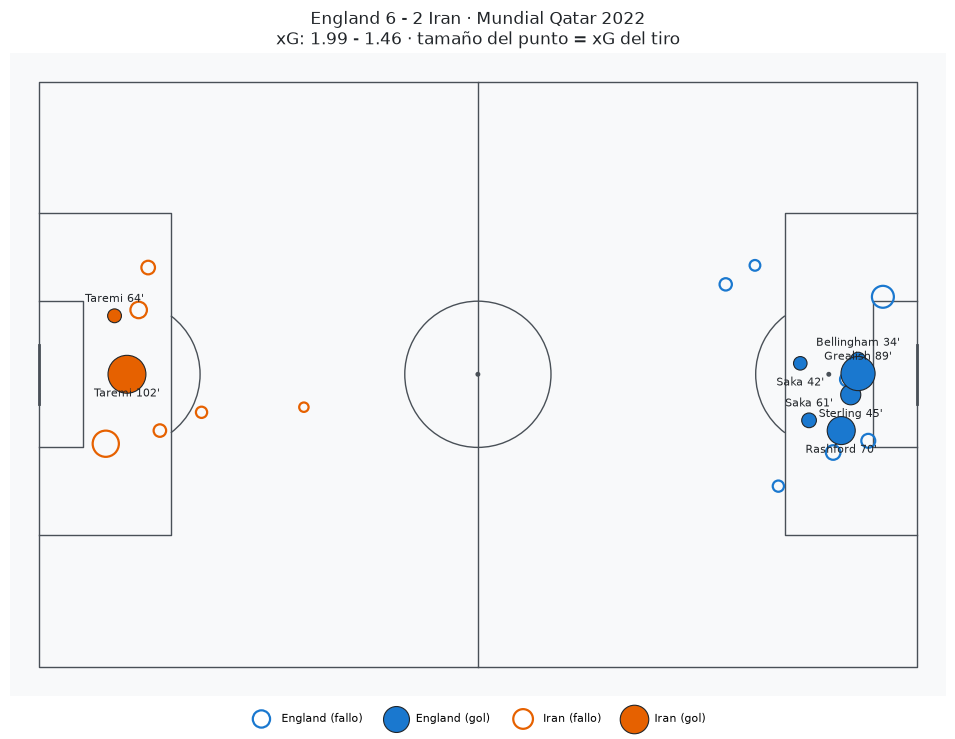

In [2]:
shots = df[df.type_name == "Shot"].copy()
shots[["x", "y"]] = pd.DataFrame(shots.location.tolist(), index=shots.index)
# Irán atacando hacia la izquierda: se invierten sus coordenadas
mask_b = shots.team_name == TEAM_B
shots.loc[mask_b, "x"] = 120 - shots.loc[mask_b, "x"]
shots.loc[mask_b, "y"] = 80 - shots.loc[mask_b, "y"]

pitch = Pitch(**PITCH_KW)
fig, ax = pitch.draw(figsize=(11, 7.5))
for team, color in ((TEAM_A, COLOR_A), (TEAM_B, COLOR_B)):
    t = shots[shots.team_name == team]
    goals, misses = t[t.shot_outcome_name == "Goal"], t[t.shot_outcome_name != "Goal"]
    pitch.scatter(misses.x, misses.y, s=misses.shot_statsbomb_xg * 900 + 40,
                  facecolor="none", edgecolor=color, linewidth=1.6, ax=ax, label=f"{team} (fallo)")
    pitch.scatter(goals.x, goals.y, s=goals.shot_statsbomb_xg * 900 + 40,
                  color=color, edgecolor="#212529", linewidth=0.8, ax=ax, label=f"{team} (gol)")
    # etiquetas alternadas arriba/abajo para que no colisionen en zonas densas
    for i, (_, g) in enumerate(goals.sort_values("y").iterrows()):
        dy = 10 if i % 2 == 0 else -16
        ax.annotate(f"{g.player_name.split()[-1]} {g.minute}'", (g.x, g.y),
                    xytext=(0, dy), textcoords="offset points",
                    ha="center", fontsize=8, color="#212529")

xg_a = shots[shots.team_name == TEAM_A].shot_statsbomb_xg.sum()
xg_b = shots[shots.team_name == TEAM_B].shot_statsbomb_xg.sum()
ax.set_title(f"{TEAM_A} 6 - 2 {TEAM_B} · Mundial Qatar 2022\n"
             f"xG: {xg_a:.2f} - {xg_b:.2f} · tamaño del punto = xG del tiro",
             fontsize=12, color="#212529")
ax.legend(loc="lower center", ncol=4, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.06))
fig.savefig(FIGS / "shot_map.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

## 2. Mapa de calor de toques de Inglaterra

Densidad KDE (kernel density estimation) sobre las ubicaciones donde Inglaterra
tocó el balón: pases, recepciones, conducciones, regates y tiros. Escala
**secuencial de un solo tono** (más oscuro = más actividad).

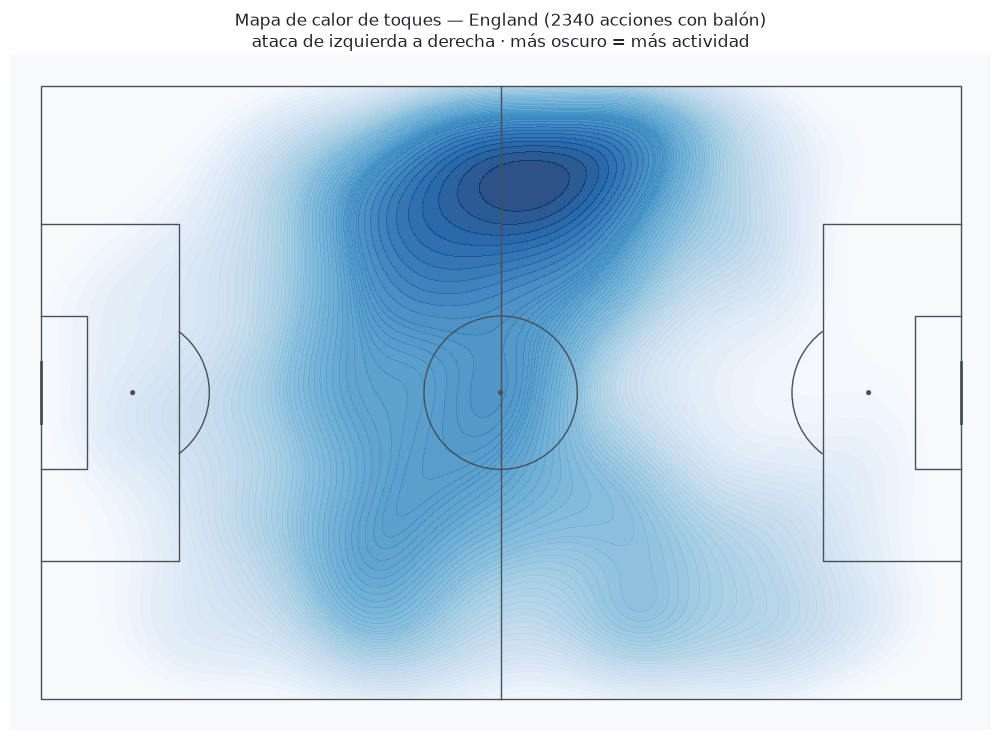

In [3]:
TOUCH_TYPES = ["Pass", "Ball Receipt*", "Carry", "Dribble", "Shot"]
touches = df[(df.team_name == TEAM_A) & df.type_name.isin(TOUCH_TYPES) & df.location.notna()].copy()
touches[["x", "y"]] = pd.DataFrame(touches.location.tolist(), index=touches.index)

pitch = Pitch(**PITCH_KW)
fig, ax = pitch.draw(figsize=(11, 7.5))
pitch.kdeplot(touches.x, touches.y, ax=ax, fill=True, levels=60, thresh=0.03,
              cmap="Blues", alpha=0.85, zorder=0.5)
ax.set_title(f"Mapa de calor de toques — {TEAM_A} ({len(touches)} acciones con balón)\n"
             "ataca de izquierda a derecha · más oscuro = más actividad",
             fontsize=12, color="#212529")
fig.savefig(FIGS / "heatmap_touches.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

## 3. Red de pases de Inglaterra (once inicial)

Cada nodo es un titular en su **posición media**; su tamaño refleja cuántos pases
jugó. El grosor de cada línea es el **volumen de pases entre esa pareja** (mínimo 3).
Se corta en la primera sustitución para que las posiciones medias sean comparables.
La formación sale del evento `Starting XI`.

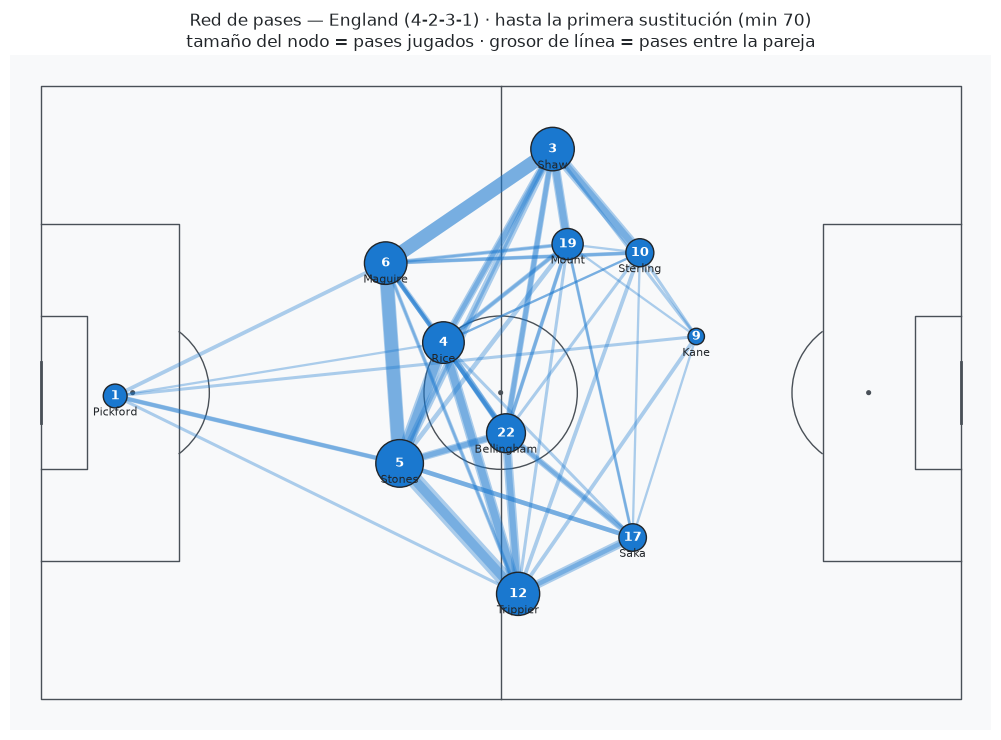

In [4]:
xi = df[(df.type_name == "Starting XI") & (df.team_name == TEAM_A)].iloc[0]
formation = "-".join(str(int(xi.tactics_formation)))
jersey = {p["player"]["name"]: p["jersey_number"] for p in xi.tactics_lineup}

first_sub = df[(df.type_name == "Substitution") & (df.team_name == TEAM_A)].minute.min()
passes = df[(df.type_name == "Pass") & (df.team_name == TEAM_A)
            & df.pass_recipient_name.notna() & (df.minute < first_sub)].copy()
passes[["x", "y"]] = pd.DataFrame(passes.location.tolist(), index=passes.index)

avg_pos = passes.groupby("player_name")[["x", "y"]].mean()
volume = passes.player_name.value_counts()
links = (passes.groupby(["player_name", "pass_recipient_name"]).size()
         .reset_index(name="n").query("n >= 3"))

pitch = Pitch(**PITCH_KW)
fig, ax = pitch.draw(figsize=(11, 7.5))
for _, l in links.iterrows():
    if l.player_name in avg_pos.index and l.pass_recipient_name in avg_pos.index:
        p1, p2 = avg_pos.loc[l.player_name], avg_pos.loc[l.pass_recipient_name]
        pitch.lines(p1.x, p1.y, p2.x, p2.y, lw=l.n * 0.55, color=COLOR_A,
                    alpha=0.35, zorder=1, ax=ax)
pitch.scatter(avg_pos.x, avg_pos.y, s=volume.reindex(avg_pos.index) * 14,
              color=COLOR_A, edgecolor="#212529", linewidth=1, zorder=2, ax=ax)
for name, pos in avg_pos.iterrows():
    ax.annotate(jersey.get(name, "?"), (pos.x, pos.y), ha="center", va="center",
                fontsize=9, fontweight="bold", color="white", zorder=3)
    ax.annotate(name.split()[-1], (pos.x, pos.y), xytext=(0, -14),
                textcoords="offset points", ha="center", fontsize=8, color="#212529", zorder=3)
ax.set_title(f"Red de pases — {TEAM_A} ({formation}) · hasta la primera sustitución (min {first_sub})\n"
             "tamaño del nodo = pases jugados · grosor de línea = pases entre la pareja",
             fontsize=12, color="#212529")
fig.savefig(FIGS / "pass_network.png", dpi=200, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

## 4. Estadísticas de jugadores del partido

Todo esto sale de la misma tabla de eventos — es la base de los dashboards
de jugador (radares, percentiles) de las fases siguientes.

In [5]:
stats = []
for player, g in df[df.player_name.notna()].groupby("player_name"):
    p = g[g.type_name == "Pass"]
    stats.append({
        "jugador": player,
        "equipo": g.team_name.iloc[0],
        "pases": len(p),
        "pases_completados": int(p.pass_recipient_name.notna().sum()),
        "tiros": int((g.type_name == "Shot").sum()),
        "xg": round(g.shot_statsbomb_xg.sum(), 2) if "shot_statsbomb_xg" in g else 0.0,
        "goles": int((g.shot_outcome_name == "Goal").sum()) if "shot_outcome_name" in g else 0,
        "regates": int((g.type_name == "Dribble").sum()),
        "presiones": int((g.type_name == "Pressure").sum()),
    })
stats = pd.DataFrame(stats).sort_values("xg", ascending=False)
stats.head(12)

,jugador,equipo,pases,pases_completados,tiros,xg,goles,regates,presiones
20,Mehdi Taremi,Iran,21,18,3,0.91,2,2,22
12,Jack Grealish,England,19,19,1,0.63,1,0,7
18,Marcus Rashford,England,20,18,2,0.49,1,3,5
30,Sardar Azmoun,Iran,4,4,1,0.35,0,0,0
11,Harry Maguire,England,72,67,2,0.30,0,1,4
26,Raheem Sterling,England,29,29,1,0.19,1,3,4
5,Bukayo Saka,England,29,28,3,0.17,2,2,14
3,Alireza Jahanbakhsh,Iran,8,6,1,0.11,0,1,12
15,Jude Bellingham,England,102,98,1,0.08,1,2,13
19,Mason Mount,England,37,36,1,0.07,0,1,11
